In [1]:
#input files. Do not touch.
import pandas as pd
import glob
import re

# Load training.csv
training = pd.read_csv("training.csv")

# Load all evalN.csv files into separate dataframes named evaluationN
eval_files = glob.glob("eval*.csv")
for f in eval_files:
    match = re.search(r'eval(\d+)\.csv', f)
    if match:
        n = match.group(1)
        df_name = f"evaluation{n}"
        globals()[df_name] = pd.read_csv(f)
        print("found evaluation dataset n°: " + df_name)

found evaluation dataset n°: evaluation1
found evaluation dataset n°: evaluation2
found evaluation dataset n°: evaluation3
found evaluation dataset n°: evaluation6
found evaluation dataset n°: evaluation4
found evaluation dataset n°: evaluation5


In [2]:
from collections import defaultdict, deque

import numpy as np
import pandas as pd


REQUIRED = ("timestamp", "arbitration_id", "data_field")
MAX_CAN_ID = 0x1FFFFFFF
MIN_DELTA_TRANSITIONS = 200
INNER_TRAIN_FRACTION = 0.80
MAX_VALIDATION_UNSEEN_RATE = 0.001
STRONG_HAMMING_QUANTILE = 0.999
WEAK_SCORE_MAD_MULTIPLIER = 3.0
MIN_WEAK_SCORE_SCALE = 1.0
MIN_PERIOD_INTERVALS = 200
REPEAT_PERIODS = 3.0
CANDIDATE_CONFIRMATIONS = 2


def _parse_id(value):
    if pd.isna(value):
        return -1
    text = str(value).strip().upper()
    if text.startswith("0X"):
        text = text[2:]
    try:
        value = int(text, 16)
    except (TypeError, ValueError):
        return -1
    return value if 0 <= value <= MAX_CAN_ID else -1


def _parse_payload(value):
    if pd.isna(value):
        return None, -1
    text = "".join(str(value).strip().split())
    if text.lower().startswith("0x"):
        text = text[2:]
    if not text or len(text) % 2:
        return None, -1
    try:
        raw = bytes.fromhex(text)
    except ValueError:
        return None, -1
    if not 1 <= len(raw) <= 8:
        return None, -1
    return raw.ljust(8, b"\x00"), len(raw)


def _normalise(frame):
    """Proietta il DataFrame sulle sole tre colonne consentite."""
    missing = set(REQUIRED).difference(frame.columns)
    if missing:
        raise ValueError(f"Colonne mancanti: {sorted(missing)}")
    data = frame.loc[:, list(REQUIRED)]
    n = len(data)
    timestamps = pd.to_numeric(data["timestamp"], errors="coerce").to_numpy(
        dtype=np.float64
    )
    can_ids = np.fromiter(
        (_parse_id(x) for x in data["arbitration_id"]),
        dtype=np.int64,
        count=n,
    )
    payloads = np.zeros((n, 8), dtype=np.uint8)
    dlcs = np.full(n, -1, dtype=np.int8)
    for i, value in enumerate(data["data_field"]):
        raw, dlc = _parse_payload(value)
        if raw is not None:
            payloads[i] = np.frombuffer(raw, dtype=np.uint8)
            dlcs[i] = dlc
    return timestamps, can_ids, payloads, dlcs


def _ordered_positions(timestamps, mask=None):
    positions = np.arange(len(timestamps)) if mask is None else np.flatnonzero(mask)
    values = np.where(np.isfinite(timestamps[positions]),
                      timestamps[positions], np.inf)
    return positions[np.argsort(values, kind="stable")]


def _circular_distance(delta, allowed):
    return min(
        min((delta - normal) % 256, (normal - delta) % 256)
        for normal in allowed
    )


def _distance_table(allowed):
    """Distanza 0..128 di ogni possibile delta dal supporto normale."""
    if not allowed:
        return np.full(256, 128, dtype=np.uint8)
    return np.fromiter(
        (_circular_distance(delta, allowed) for delta in range(256)),
        dtype=np.uint8,
        count=256,
    )


def _fit_delta_rule(messages):
    deltas = np.diff(messages.astype(np.int16), axis=0) % 256
    n = len(deltas)
    enabled = np.zeros(messages.shape[1], dtype=bool)
    validation_unseen = np.ones(messages.shape[1], dtype=np.float32)
    allowed = []

    for byte in range(messages.shape[1]):
        allowed.append(frozenset(int(x) for x in np.unique(deltas[:, byte])))
        if n < MIN_DELTA_TRANSITIONS:
            continue
        split = max(1, int(n * INNER_TRAIN_FRACTION))
        learned = set(int(x) for x in deltas[:split, byte])
        check = deltas[split:, byte]
        unseen = np.fromiter(
            (int(x) not in learned for x in check), bool, count=len(check)
        )
        validation_unseen[byte] = float(unseen.mean()) if len(unseen) else 1.0
        enabled[byte] = validation_unseen[byte] <= MAX_VALIDATION_UNSEEN_RATE

    return {
        "allowed_modular_deltas": tuple(allowed),
        "enabled": enabled,
        "validation_unseen_rate": validation_unseen,
    }


def _weak_validation_scores(messages, rule):
    """Score positivi prodotti dal validation tail del singolo stream."""
    deltas = np.diff(messages.astype(np.int16), axis=0) % 256
    if not len(deltas):
        return []
    split = max(1, int(len(deltas) * INNER_TRAIN_FRACTION))
    enabled = np.flatnonzero(rule["enabled"])
    learned = tuple(
        frozenset(int(x) for x in np.unique(deltas[:split, byte]))
        for byte in range(messages.shape[1])
    )
    scores = []
    for row in deltas[split:]:
        score = sum(
            _circular_distance(int(row[byte]), learned[byte])
            for byte in enabled
        )
        if score > 0:
            scores.append(score)
    return scores


def _transition_score(previous, current, rule, distance_tables):
    deltas = (current.astype(np.int16) - previous.astype(np.int16)) % 256
    return sum(
        int(distance_tables[byte][deltas[byte]])
        for byte in np.flatnonzero(rule["enabled"])
    )


def _transition_is_valid(previous, current, rule):
    deltas = (current.astype(np.int16) - previous.astype(np.int16)) % 256
    return all(
        int(deltas[byte]) in rule["allowed_modular_deltas"][byte]
        for byte in np.flatnonzero(rule["enabled"])
    )


def _hamming_distance(previous, current, enabled):
    xor = np.bitwise_xor(previous[enabled], current[enabled])
    return int(np.unpackbits(xor).sum())


def _fit_hamming_limit(messages, enabled):
    enabled = np.flatnonzero(enabled)
    if len(messages) < 2 or not len(enabled):
        return 65
    xor = np.bitwise_xor(messages[1:, enabled], messages[:-1, enabled])
    distances = np.unpackbits(xor, axis=1).sum(axis=1)
    return int(np.ceil(np.quantile(distances, STRONG_HAMMING_QUANTILE)))


def fit_profile(training_df):
    timestamps, can_ids, payloads, dlcs = _normalise(training_df)
    valid = np.isfinite(timestamps) & (can_ids >= 0) & (dlcs >= 0)
    if not valid.any():
        raise ValueError("Il training non contiene frame CAN validi")

    known_ids = frozenset(int(x) for x in np.unique(can_ids[valid]))
    allowed_dlcs = {
        aid: frozenset(int(x) for x in np.unique(dlcs[valid & (can_ids == aid)]))
        for aid in known_ids
    }
    delta_rules = {}
    hamming_limits = {}
    repeat_horizons = {}
    weak_scores = []

    keys = [(aid, dlc) for aid, values in allowed_dlcs.items() for dlc in values]
    for key in keys:
        mask = valid & (can_ids == key[0]) & (dlcs == key[1])
        positions = _ordered_positions(timestamps, mask)
        messages = payloads[positions, :key[1]]
        if len(messages) >= 2:
            rule = _fit_delta_rule(messages)
            delta_rules[key] = rule
            hamming_limits[key] = _fit_hamming_limit(messages, rule["enabled"])
            weak_scores.extend(_weak_validation_scores(messages, rule))

        intervals = np.diff(timestamps[positions])
        intervals = intervals[np.isfinite(intervals) & (intervals > 0)]
        if len(intervals) >= MIN_PERIOD_INTERVALS:
            repeat_horizons[key] = max(
                float(np.quantile(intervals, 0.99)),
                REPEAT_PERIODS * float(np.median(intervals)),
            )

    if weak_scores:
        weak_median = float(np.median(weak_scores))
        weak_mad = float(np.median(np.abs(np.asarray(weak_scores) - weak_median)))
        weak_score_limit = int(np.ceil(
            weak_median
            + WEAK_SCORE_MAD_MULTIPLIER * max(weak_mad, MIN_WEAK_SCORE_SCALE)
        ))
    else:
        weak_median = weak_mad = 0.0
        weak_score_limit = 0

    recent = defaultdict(deque)
    max_repeats = defaultdict(int)
    for position in _ordered_positions(timestamps, valid):
        structure = (int(can_ids[position]), int(dlcs[position]))
        horizon = repeat_horizons.get(structure)
        if horizon is None:
            continue
        token = payloads[position, :structure[1]].tobytes()
        history = recent[(structure, token)]
        now = float(timestamps[position])
        while history and now - history[0] > horizon:
            history.popleft()
        max_repeats[structure] = max(max_repeats[structure], len(history))
        history.append(now)

    return {
        "known_ids": known_ids,
        "allowed_dlcs": allowed_dlcs,
        "delta_rules": delta_rules,
        "hamming_limits": hamming_limits,
        "weak_score_limit": weak_score_limit,
        "weak_score_median": weak_median,
        "weak_score_mad": weak_mad,
        "weak_score_samples": len(weak_scores),
        "repeat_horizons": repeat_horizons,
        "max_repeats": dict(max_repeats),
        "candidate_confirmations": CANDIDATE_CONFIRMATIONS,
        "training_rows": int(len(training_df)),
        "valid_training_rows": int(valid.sum()),
    }


def make_ids(profile):
    known_ids = profile["known_ids"]
    allowed_dlcs = profile["allowed_dlcs"]
    delta_rules = profile["delta_rules"]
    hamming_limits = profile["hamming_limits"]
    weak_limit = profile["weak_score_limit"]
    repeat_horizons = profile["repeat_horizons"]
    max_repeats = profile["max_repeats"]
    confirmations = profile["candidate_confirmations"]
    distance_tables = {
        key: tuple(_distance_table(values)
                   for values in rule["allowed_modular_deltas"])
        for key, rule in delta_rules.items()
    }

    def ids(eval_df):
        timestamps, can_ids, payloads, dlcs = _normalise(eval_df)
        attacks = np.zeros(len(eval_df), dtype=bool)
        trusted = {}
        candidates = {}
        candidate_streak = defaultdict(int)
        latched = set()
        recent = defaultdict(deque)

        for position in _ordered_positions(timestamps):
            aid, dlc = int(can_ids[position]), int(dlcs[position])
            well_formed = (
                np.isfinite(timestamps[position]) and aid >= 0 and dlc >= 0
            )
            structure = (aid, dlc)
            known_structure = (
                well_formed
                and aid in known_ids
                and dlc in allowed_dlcs.get(aid, ())
            )
            if not known_structure:
                attacks[position] = True
                continue

            current = payloads[position, :dlc]
            rule = delta_rules.get(structure)
            previous = trusted.get(structure)
            score = (
                _transition_score(
                    previous, current, rule, distance_tables[structure]
                )
                if previous is not None and rule is not None
                else 0
            )
            transition_bad = score > 0

            if structure in latched:
                if transition_bad:
                    attacks[position] = True
                else:
                    trusted[structure] = current.copy()
                    latched.remove(structure)
                    candidates.pop(structure, None)
                    candidate_streak[structure] = 0
            elif previous is None or not transition_bad:
                trusted[structure] = current.copy()
                candidates.pop(structure, None)
                candidate_streak[structure] = 0
            else:
                enabled = np.flatnonzero(rule["enabled"])
                strong = (
                    _hamming_distance(previous, current, enabled)
                    > hamming_limits[structure]
                )
                if strong:
                    attacks[position] = True
                    latched.add(structure)
                    candidates.pop(structure, None)
                    candidate_streak[structure] = 0
                elif score <= weak_limit:
                    # Piccolo scostamento normale: accettalo ed evita la cascata.
                    trusted[structure] = current.copy()
                    candidates.pop(structure, None)
                    candidate_streak[structure] = 0
                else:
                    attacks[position] = True
                    candidate = candidates.get(structure)
                    candidate_ok = (
                        candidate is not None
                        and _transition_is_valid(candidate, current, rule)
                    )
                    candidates[structure] = current.copy()
                    candidate_streak[structure] = (
                        candidate_streak[structure] + 1 if candidate_ok else 1
                    )
                    if candidate_streak[structure] >= confirmations:
                        trusted[structure] = current.copy()
                        candidates.pop(structure, None)
                        candidate_streak[structure] = 0

            horizon = repeat_horizons.get(structure)
            if horizon is not None:
                token = current.tobytes()
                history = recent[(structure, token)]
                now = float(timestamps[position])
                while history and now - history[0] > horizon:
                    history.popleft()
                if len(history) > max_repeats.get(structure, 0):
                    attacks[position] = True
                history.append(now)

        result = eval_df.copy()
        result["predicted_attack"] = attacks.astype(np.int8)
        return result

    ids.profile = profile
    return ids


def build_ids(training_df):
    return make_ids(fit_profile(training_df))


if "training" in globals():
    ids = build_ids(training)
    ids_profile = ids.profile


running evaluation1
running evaluation2
running evaluation3
running evaluation6
running evaluation4
running evaluation5

evaluation1 Evaluation Metrics:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1_score: 1.0000

evaluation2 Evaluation Metrics:
  Accuracy: 0.9933
  Precision: 0.9527
  Recall: 1.0000
  F1_score: 0.9758

evaluation3 Evaluation Metrics:
  Accuracy: 0.9887
  Precision: 0.6718
  Recall: 0.9778
  F1_score: 0.7964

evaluation6 Evaluation Metrics:
  Accuracy: 0.9975
  Precision: 0.9361
  Recall: 0.9719
  F1_score: 0.9537

evaluation4 Evaluation Metrics:
  Accuracy: 0.9994
  Precision: 0.9996
  Recall: 0.9985
  F1_score: 0.9991

evaluation5 Evaluation Metrics:
  Accuracy: 0.9790
  Precision: 0.5201
  Recall: 1.0000
  F1_score: 0.6843

Average Evaluation Metrics:
  Accuracy: 0.9930
  Precision: 0.8467
  Recall: 0.9914
  F1_score: 0.9015


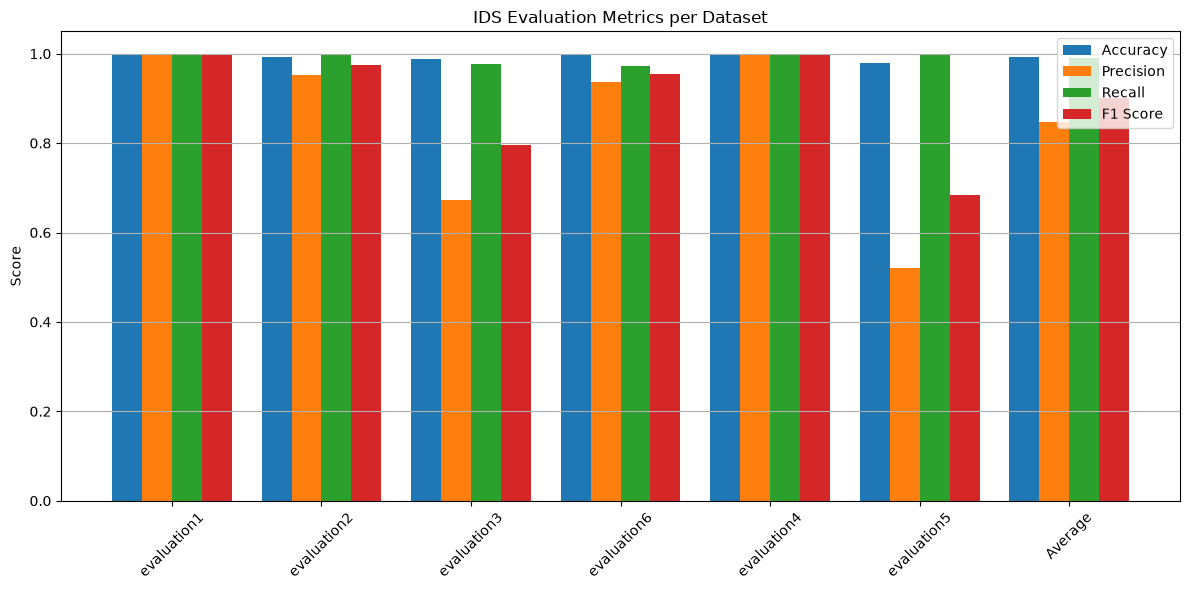


Total Elapsed Time: 1.11 seconds


In [3]:
#evaluation sequence. Do not touch.
import time  # Add this
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

start_time = time.time()  # Start timing

evaluation_metrics = {}
all_globals = list(globals().items())

# Loop through evaluation dataframes
for name, df in all_globals:
    if name.startswith("evaluation") and isinstance(df, pd.DataFrame):
        # Run IDS
        print("running " + name)
        detected_df = ids(df)
        
        # Compare predictions to ground truth
        y_true = detected_df['attack']
        y_pred = detected_df['predicted_attack']
        
        # Compute metrics
        metrics = {
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1_score': f1_score(y_true, y_pred, zero_division=0),
        }
        
        evaluation_metrics[name] = metrics

# Compute average metrics
avg_metrics = {
    metric: np.mean([metrics[metric] for metrics in evaluation_metrics.values()])
    for metric in ['accuracy', 'precision', 'recall', 'f1_score']
}
evaluation_metrics['Average'] = avg_metrics

# Display metrics
for name, metrics in evaluation_metrics.items():
    print(f"\n{name} Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"  {metric.capitalize()}: {value:.4f}")

# Plotting
labels = list(evaluation_metrics.keys())
x = np.arange(len(labels))
width = 0.2

# Prepare metric lists
accuracy = [evaluation_metrics[label]['accuracy'] for label in labels]
precision = [evaluation_metrics[label]['precision'] for label in labels]
recall = [evaluation_metrics[label]['recall'] for label in labels]
f1 = [evaluation_metrics[label]['f1_score'] for label in labels]

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1, width, label='F1 Score')

plt.xticks(x, labels, rotation=45)
plt.ylabel('Score')
plt.title('IDS Evaluation Metrics per Dataset')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.grid(axis='y')
plt.show()

# End timing
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal Elapsed Time: {elapsed_time:.2f} seconds")
